In [1]:
from matplotlib import cm
from matplotlib import pyplot as plt
import numpy as np


## Rosenbrock function

The Rosenbrock function, introduced by Howard Rosenbrock in 1960, is a non-convex function  commonly used to evaluate optimization procedures. It has a narrow curved valley. In general finding the valley is easy, due to its steep walls. However, the valley floor is curved, with shallow gradients, making it hard to achieve the global minimum.

$\large f(x,y) = (a-x)^2 + b(y-x^2)^2$

The function has a global minimum at $(a,a^2)$, with $f(a,a^2) = 0$

Other test functions for optimization can be found in [wikipedia](https://en.wikipedia.org/wiki/Test_functions_for_optimization).



In [2]:
def rosenbrock(x,y, a = 1, b = 10):
    return (a - x)**2 + b * (y - x**2)**2

In [3]:
# settings for function evaluation

a = 1
b = 10
xx = np.linspace(-2, 2, 100)
yy = np.linspace(-1, 3, 100)

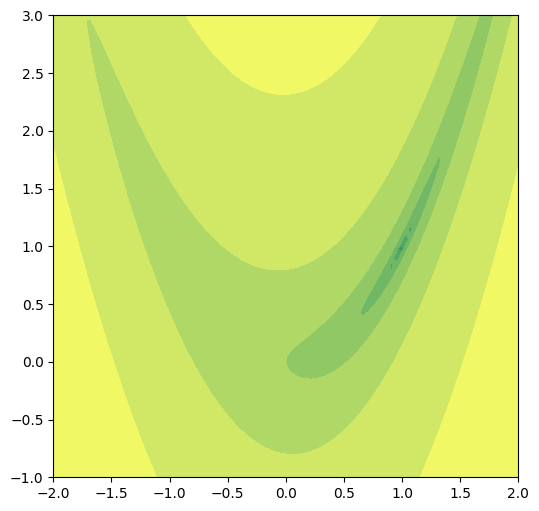

In [4]:
zz = np.asarray([[rosenbrock(x,y,a,b) for x in xx] for y in yy])
zz_safe = np.where(zz > 0, zz, np.nan)
plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, np.log(zz_safe), cmap=cm.summer)

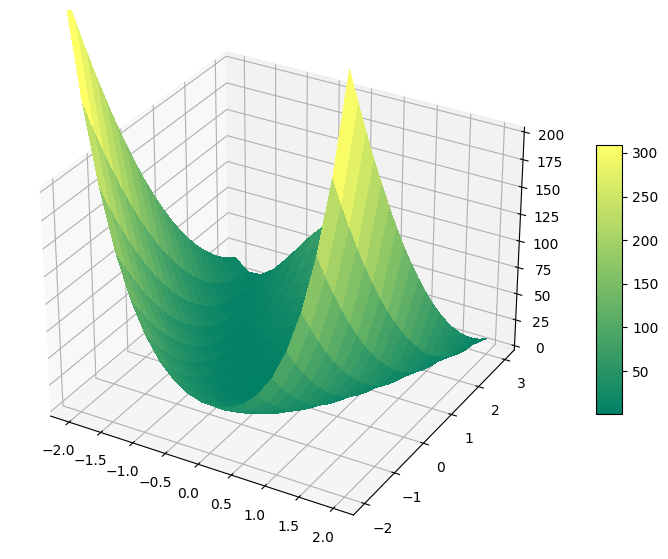

In [5]:
from matplotlib import cm
#from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D

# Initialize figure 
figRos = plt.figure(figsize=(12, 7))
#axRos = figRos.gca(projection='3d')
axRos = plt.axes(projection='3d')
# Evaluate function
X = np.linspace(-2, 2, 20)
Y = np.linspace(-2, 3, 20)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock(X,Y)

# Plot the surface
surf = axRos.plot_surface(X,Y,Z, cmap=cm.summer,
                       linewidth=0, antialiased=False)
axRos.set_zlim(0, 200)
figRos.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

## Optimizers

Deep learning optimizers are commonly iterative procedures based on gradient information. In here the following optimizers will be presented:

* Gradient descent
* Gradient descent with momentum
* RMSProp
* Adam
* Adamax

For the Rosenbrock function the gradient can be computed as:

$\large g(x,y) =  {\large(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}) }= (2(x-a) - 4b*(y - x^2)x, 2b(y-x^2))$


In [6]:
# function to compute the partial derivatives

def df_rosenbrock(P,a=1, b=10):
    x = P[0]
    y = P[1]
    return (2*(x-1) - 4*b*(y - x**2)*x, 2*b*(y-x**2))

In [7]:
# general parameters for all optimizers

steps = 100
start = [-1.8,2.6]

In [8]:
# aux function to plot contours and optimizer path

def plot_optimizer(xx,yy,zz,path):
    plt.figure(figsize=(8, 8))
    plt.contour(xx,yy,zz,250, cmap=cm.plasma)


    plt.plot([start[0]],[start[1]],marker='o',markersize=4, color ='g')
    for i in range(steps):
        plt.plot([path[i][0]],[path[i][1]],marker='o',markersize=2, color ='r')
        plt.arrow(path[i][0], path[i][1],path[i+1][0]-path[i][0], path[i+1][1]-path[i][1], head_width=0.05, head_length=0.05, fc='r', ec='r')
    
    plt.plot([1],[1],marker='o',markersize=2, color ='b')    

In [9]:
def plot_loss_curve(losses, lr=None, label=None, title_prefix=''):
    plt.figure(figsize=(6, 4))
    plt.plot(losses, label=label if label is not None else 'loss')
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x, y)')
    if lr is not None:
        title = f'{title_prefix} loss vs iteration (lr = {lr:.3g})'
    else:
        title = f'{title_prefix} loss vs iteration'
    plt.title(title)
    if label is not None:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


### Gradient Descent

This is the plain version, just follow the inverse direction of the gradient. Assuming $p$ is our initial guess, and f is the function we want to find the minimum of:

$\nabla f = \large (\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}) $

$\large p = p - \alpha \nabla f$

where $\alpha$ is the learning rate

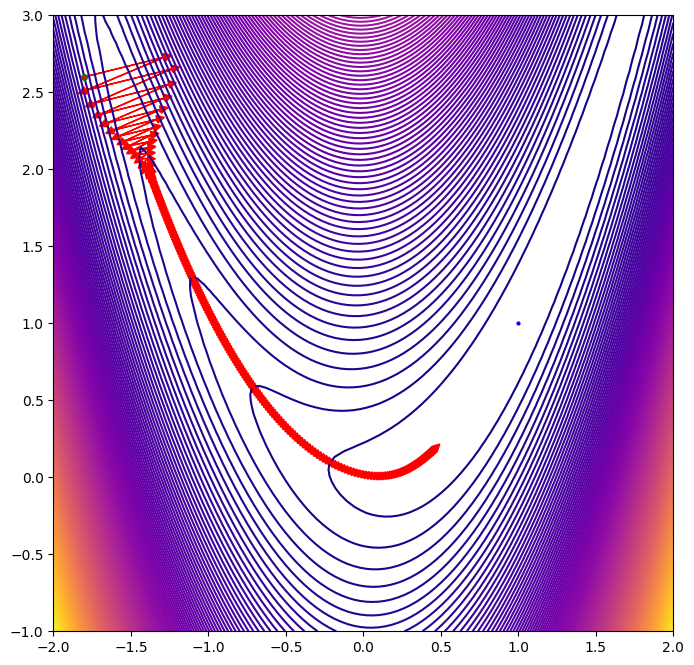

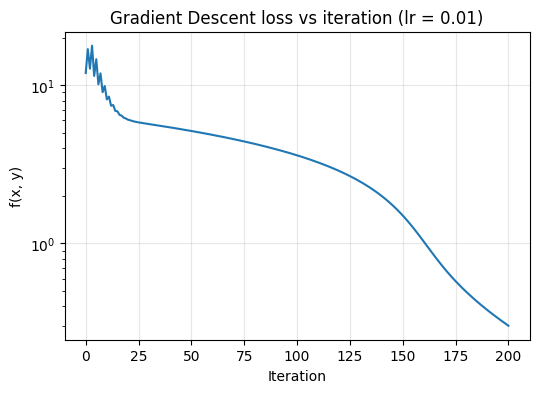

In [10]:
# Gradient descent

steps = 200
lr = 0.01
point = start.copy()
gx = [point.copy()]
losses = []

for i in range(steps):
    x, y = point
    losses.append(rosenbrock(x, y))          # current loss

    df = df_rosenbrock(point)
    point -= lr * np.asarray(df)
    gx.append(point.copy())

# optionally store final loss
x, y = point
losses.append(rosenbrock(x, y))

plot_optimizer(xx, yy, zz, gx)
plot_loss_curve(losses, lr=lr, title_prefix='Gradient Descent')


### Gradient descent with momentum

Recall that in plain gradient descent we update

$
\large p = p - \alpha \nabla f
$

where $p$ is the current point, $\nabla f$ is the gradient, and $\alpha$ is the learning rate.

With momentum, we keep track of the previous step $s$ and update in two stages:

1. Compute the new step from the gradient:
$
\large s = - \alpha \nabla f
$

2. Update the point by adding the new step and a fraction of the previous step:
$
\large p = p + s + \mu s_{\text{prev}}
$

where $\mu$ is the momentum coefficient and $s_{\text{prev}}$ is the step from the previous iteration.

This way, the update direction combines the current gradient step with a fraction of the previous step, which helps accelerate progress along directions of consistent descent and damp oscillations.


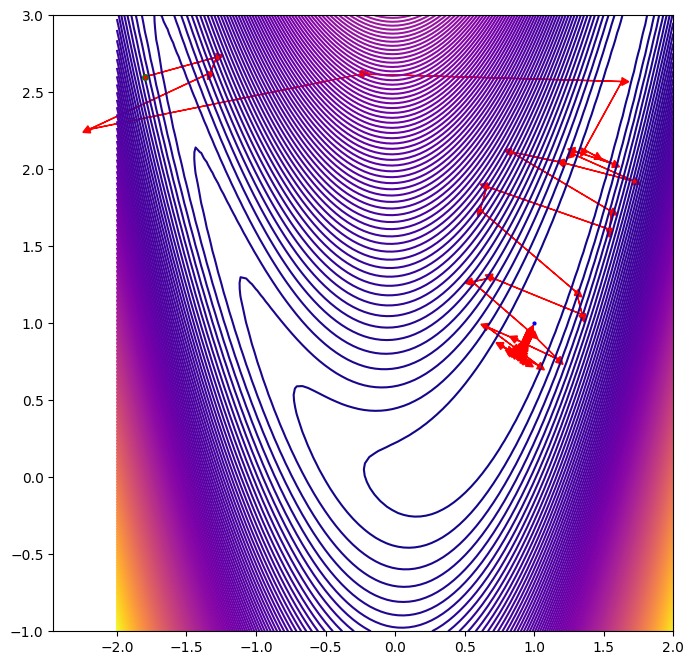

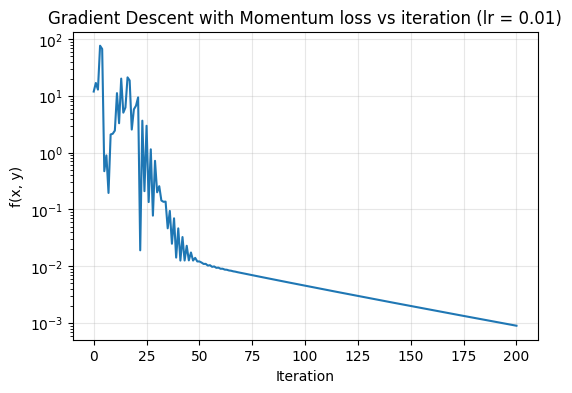

In [11]:
# Gradient descent with momentum

# parameters
steps = 200
lr = 0.01
m  = 0.9

# init
point = start.copy()
gx = [point.copy()]
losses = []

prev_step = np.asarray((0.0, 0.0), dtype=np.float64)

for i in range(steps):
    # current loss
    x, y = point
    losses.append(rosenbrock(x, y))

    # gradient
    df = df_rosenbrock(point)
    step = - lr * np.asarray(df, dtype=np.float64)

    # momentum update
    point += step + m * prev_step
    prev_step = step
    gx.append(point.copy())

# optional final loss
x, y = point
losses.append(rosenbrock(x, y))

# trajectory on contour
plot_optimizer(xx, yy, zz, gx)

# loss vs iteration
plot_loss_curve(losses, lr=lr, title_prefix='Gradient Descent with Momentum')


### RMSProp (Root Mean Square Propagation)

As can be seen above, the **sign** of the gradient is a very useful information, however, the **magnitude** can be way off: 

* when on the wall of the valley the gradient can be very large and overshoot the target taking us to the other side of the valley, potentially at a greater height than before;

* on the other hand, when close to the target, gradients tend to be shallow, hence, gradients have very small magnitude, taking a long time to actually achieve the minimum.

In the first case we need a **small learning rate**, whereas in the latter example we need a **larger learning rate**.

RMSProp keeps a running average of the squared gradients and uses it to adapt the effective learning rate for each direction:

$\large v_i = \beta v_{i-1} + (1 - \beta) (\nabla f)^2$

$ \large p = p - {\Large \frac{\alpha}{\sqrt{v_i} + \epsilon}}  \nabla f$

$v$ is a moving average of the squared gradient magnitude in each direction. Dividing the learning rate by $\sqrt{v}$ is similar to a normalization procedure. Larger gradients are divided by larger values, smaller gradients are divided by smaller values.


Pytorch default parameters:

* $\beta = 0.99$
* $\epsilon = 1e-08$

TensorFlow default parameters:

* $\beta = 0.9$
* $\epsilon = 1e-07$


Ref: Geoffrey Hinton, **RMSProp: Divide the gradient by a running average of its recent magnitude** [Video](https://www.youtube.com/watch?v=XhZahXzEuNo)

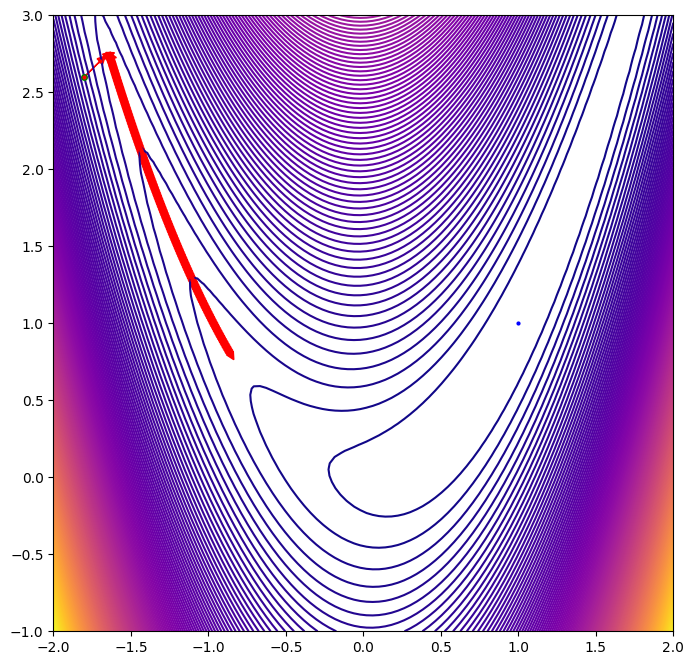

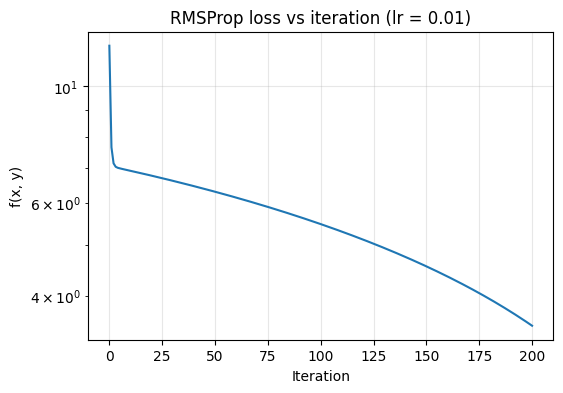

In [12]:
# RMSProp

steps = 200
lr    = 0.01
beta  = 0.99        # decay for running avg of squared gradients
eps   = 1e-8

point = start.copy()
gx = [point.copy()]
losses = []

v = np.zeros_like(point, dtype=np.float64)   # running avg of squared gradients

for i in range(steps):
    # current loss
    x, y = point
    losses.append(rosenbrock(x, y))

    # gradient
    df = np.asarray(df_rosenbrock(point), dtype=np.float64)

    # update running average of squared gradients
    v = beta * v + (1.0 - beta) * (df * df)

    # RMSProp update
    point = point - lr * df / (np.sqrt(v) + eps)

    gx.append(point.copy())

# optional final loss
x, y = point
losses.append(rosenbrock(x, y))

# plots
plot_optimizer(xx, yy, zz, gx)
plot_loss_curve(losses, lr=lr, title_prefix='RMSProp')


RMSProp makes the optimization less sensitive to the choice of learning rate. In plain gradient descent, we use a single global $\alpha$ for all directions: if $\alpha$ is slightly too large for the steep directions, the updates can overshoot the valley and the method quickly diverges. 

RMSProp instead scales the step for each direction by the inverse of the running average of its squared gradients. 

Directions where the gradient is consistently large get a large $v$ and therefore a small effective learning rate $\alpha / \sqrt{v}$, which damps overshooting. 

Directions where the gradient is usually small get a smaller $v$ and thus a relatively larger effective step. As a result, RMSProp can often use a noticeably larger base learning rate than plain gradient descent while still converging, making it more robust to imperfect learning rate choices. Nevertheless, it can still diverge if $\alpha$ is extremely large.

On the Rosenbrock example above, with $\alpha = 0.1$ RMSProp converges without 
diverging, which is something that both gradient descent with and without momentum failed for the same learning rate.

On the other hand, RMSProp is not very effective if the base learning rate $\alpha$ is too small. Because the update for each parameter is scaled by $\alpha / \sqrt{v}$, choosing a very small $\alpha$ makes all effective step sizes tiny, even in directions where $v$ is small and we would like to move more aggressively. In that case the method can converge extremely slowly or appear “stuck,” despite its adaptive rescaling. In practice, RMSProp benefits from a reasonably tuned base learning rate: not so large that it diverges, but also not so small that the adaptive behavior becomes irrelevant.

In the code above, if we set $\alpha = 0.005$ the algorithm moves extremely slowly towards the target when compared to Gradient Descent with Momentum.

### Adam

Adam is one of the most popular optimizers. The basic intuition is to combine 
the ideas of **momentum** and **RMSProp**.

We keep an exponential moving average of the gradients:

$
\large m_i = \beta_1 m_{i-1} + (1 - \beta_1)\nabla f
$

and an exponential moving average of the squared gradients:

$
\large v_i = \beta_2 v_{i-1} + (1 - \beta_2)(\nabla f)^2
$

If the starting point has small values, which is common in deep neural networks, 
and we initialize with $m_0 = v_0 = 0$, then $m_i$ and $v_i$ are biased towards 
zero in the first iterations. To correct this, Adam uses **bias-corrected** 
estimates:

$
\large \hat{m}_i = \Large \frac{m_i}{1 - \beta_1^i}, \quad
\hat{v}_i = \Large \frac{v_i}{1 - \beta_2^i}
$

The update step is then:

$
\large p_i = p_{i-1} - \alpha \Large \frac{\hat{m}_i}{\sqrt{\hat{v}_i} + \epsilon}
$

Default parameters:

* $\beta_1 = 0.9$
* $\beta_2 = 0.999$
* $\epsilon = 1\text{e-}08$

Adam adapts the step size per parameter (like RMSProp, through $\hat{v}_i$) and 
also uses momentum information (through $\hat{m}_i$). An advantage of this 
procedure is that we can often start with a relatively high learning rate and 
still get stable and fast convergence in many deep learning problems.

Ref: Diederik P. Kingma, Jimmy Ba, **Adam: A Method for Stochastic Optimization** 
[PDF](https://arxiv.org/abs/1412.6980)


Experimenting on the 2D Rosenbrock function, Adam **without** bias correction on $m_t$ we can see that it behaves more robustly for larger learning rates. The full bias‑corrected version implicitly amplifies the first updates by a factor of 

$$\frac{1}{1-\beta_1^t}$$

which tends to destabilize optimization on this narrow valley. This matches recent empirical studies showing that $m_t$ bias correction acts like an implicit learning‑rate schedule and is not generally necessary for good performance when hyper‑parameters are tuned.

Ref: Sam Laing and Antonio Orvieto. **Adam Simplified: Bias Correction Debunked** 
[PDF](https://www.arxiv.org/pdf/2511.20516.pdf)

In [13]:
def adam_full(start, lr=0.01, steps=200,
              beta1=0.9, beta2=0.999, eps=1e-7):
    mdw = 0.0
    vdw = 0.0
    point = start.copy()
    path = [point.copy()]
    losses = []

    for i in range(steps):
        x, y = point
        losses.append(rosenbrock(x, y))

        df = np.asarray(df_rosenbrock(point), dtype=np.float64)

        mdw = beta1 * mdw + (1.0 - beta1) * df
        vdw = beta2 * vdw + (1.0 - beta2) * (df ** 2)

        t = i + 1.0
        mdw_corr = mdw / (1.0 - beta1**t)
        vdw_corr = vdw / (1.0 - beta2**t)

        point = point - lr * mdw_corr / (np.sqrt(vdw_corr) + eps)
        path.append(point.copy())

    return np.array(path), np.array(losses)


def adam_no_m_bias(start, lr=0.01, steps=200,
                   beta1=0.9, beta2=0.999, eps=1e-7):
    mdw = 0.0
    vdw = 0.0
    point = start.copy()
    path = [point.copy()]
    losses = []

    for i in range(steps):
        x, y = point
        losses.append(rosenbrock(x, y))

        df = np.asarray(df_rosenbrock(point), dtype=np.float64)

        mdw = beta1 * mdw + (1.0 - beta1) * df
        vdw = beta2 * vdw + (1.0 - beta2) * (df ** 2)

        t = i + 1.0
        vdw_corr = vdw / (1.0 - beta2**t)

        point = point - lr * mdw / (np.sqrt(vdw_corr) + eps)
        path.append(point.copy())

    return np.array(path), np.array(losses)


In [14]:
from matplotlib import cm

def plot_optimizer_multi(xx, yy, zz, paths_and_labels, steps, start):
    """
    paths_and_labels: list of (path_array, label, color) tuples.
    """
    plt.figure(figsize=(8, 8))
    plt.contour(xx, yy, zz, 250, cmap=cm.plasma)

    # start point (same green) and minimum (same blue)
    plt.plot([start[0]], [start[1]], marker='o', markersize=4, color='g')
    plt.plot([1], [1], marker='o', markersize=2, color='b')

    # each optimizer path
    for path, label, color in paths_and_labels:
        path = np.asarray(path)
        for i in range(steps):
            plt.plot([path[i][0]], [path[i][1]],
                     marker='o', markersize=2, color=color)
            plt.arrow(path[i][0], path[i][1],
                      path[i+1][0] - path[i][0],
                      path[i+1][1] - path[i][1],
                      head_width=0.05, head_length=0.05,
                      fc=color, ec=color)
        # add a label at the final point for legend‑like info
        plt.plot([], [], color=color, label=label)

    plt.legend()
    plt.show()


def plot_loss_curve_multi(losses_and_labels, lr, title_prefix='Adam variants'):
    plt.figure(figsize=(8, 5))
    for losses, label, color in losses_and_labels:
        plt.plot(losses, color=color, label=label)
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title(f'{title_prefix} (lr={lr})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



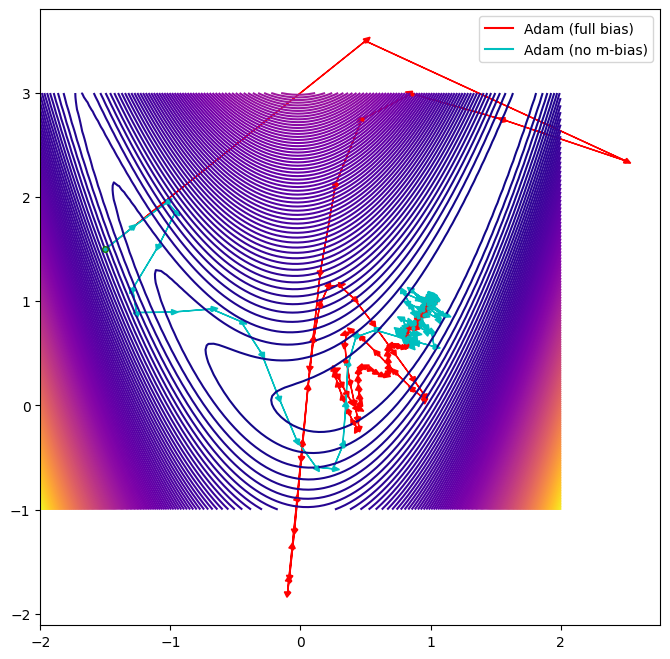

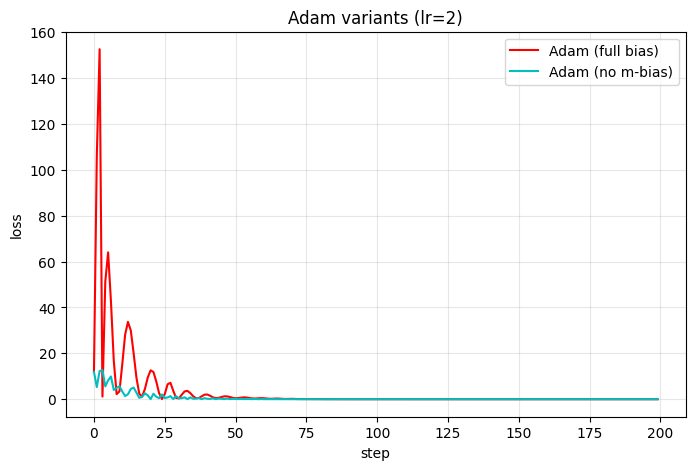

In [15]:
start = np.array([-1.5, 1.5])
lr = 2
steps = 200

optims = [
    ("Adam (full bias)",  adam_full,      'r'),
    ("Adam (no m-bias)",  adam_no_m_bias, 'c'),
]

paths_and_labels = []
losses_and_labels = []

for name, opt, color in optims:
    path, losses = opt(start, lr=lr, steps=steps)
    paths_and_labels.append((path, name, color))
    losses_and_labels.append((losses, name, color))

plot_optimizer_multi(xx, yy, zz, paths_and_labels, steps, start)
plot_loss_curve_multi(losses_and_labels, lr=lr, title_prefix='Adam variants')


Like RMSProp, Adam adapts the step size per parameter, but it still depends on the base learning rate $\alpha$. 

If $\alpha$ is chosen too small, all effective step sizes become tiny, even though Adam rescales them using $\hat{v}_i$. 

In this case the optimizer may converge extremely slowly or appear to stop making progress, especially on problems like Rosenbrock where many tiny steps are needed to follow the valley.

### Adamax

Adamax is a variant of Adam based on the $\ell_\infty$ (infinite) norm of the 
gradients. Instead of looking at some average size of the gradient components, the 
$\ell_\infty$  norm just looks at the largest component. 

In other words, it asks: “how big is the biggest coordinate of this vector?” 

For Adamax, this means $s_i$ is controlled by the maximum absolute gradient seen recently in each coordinate. If any component of the gradient becomes very large, the update is scaled down based on that largest value, which helps keep the step size under control even when some gradients spike.




It keeps a moving average of the gradients (like Adam) and a 
separate running estimate of the maximum magnitude of recent gradients.

We keep an exponential moving average of the gradients:

$
\large m_i = \beta_1 m_{i-1} + (1 - \beta_1)\nabla f
$

with bias-corrected version

$
\large \hat{m}_i = \Large \frac{m_i}{1 - \beta_1^{\,i}}
$

For the second term, instead of tracking an average of squared gradients, 
Adamax tracks a (scaled) maximum:

$
\large s_i = \max\left(\beta_2 \, s_{i-1}, \; |\nabla f|\right)
$

The update step is:

$
\large p_i = p_{i-1} - \alpha \Large \frac{\hat{m}_i}{s_i + \epsilon}
$

Here $s_i$ acts like an $\ell_\infty$-style normalization term: coordinates 
where recent gradients have been large get a larger $s_i$ and therefore 
smaller effective steps, while coordinates with smaller gradients get relatively 
larger steps. Compared to Adam, Adamax can be more stable when gradients have 
occasional very large spikes.

Typical parameters:

* $\beta_1 = 0.9$
* $\beta_2 = 0.999$
* (often the same defaults as for Adam)

Ref: Diederik P. Kingma, Jimmy Ba, **Adam: A Method for Stochastic Optimization** 
[PDF](https://arxiv.org/abs/1412.6980)

In this notebook we experiment with **both** versions: the full bias‑corrected Adamax using $\hat{m}_i$, and a simplified Adamax that uses $m_i$ directly (no bias correction), which on the 2D Rosenbrock often behaves more robustly for larger learning rates


In [16]:
def adamax_simplified(start, lr=0.01, steps=200,
                      beta1=0.9, beta2=0.999, eps=1e-7):
    """
    Adamax WITHOUT bias correction on m_t.
    This is the simplified version that behaved more robustly on Rosenbrock.
    """
    m = 0.0
    u = 0.0   # infinity-norm accumulator
    point = start.copy()
    path = [point.copy()]
    losses = []

    for t in range(1, steps + 1):
        x, y = point
        losses.append(rosenbrock(x, y))

        g = np.asarray(df_rosenbrock(point), dtype=np.float64)

        # first moment and infinity-norm accumulator
        m = beta1 * m + (1.0 - beta1) * g
        u = np.maximum(beta2 * u, np.abs(g))

        # Adamax update (no bias correction on m)
        point = point - lr * m / (u + eps)
        path.append(point.copy())

    return np.array(path), np.array(losses)


def adamax_bias_corrected(start, lr=0.01, steps=200,
                          beta1=0.9, beta2=0.999, eps=1e-7):
    """
    Adamax WITH bias correction on m_t.
    Matches the original Adam/Adamax definition (textbook/framework style).
    """
    m = 0.0
    u = 0.0   # infinity-norm accumulator
    point = start.copy()
    path = [point.copy()]
    losses = []

    for t in range(1, steps + 1):
        x, y = point
        losses.append(rosenbrock(x, y))

        g = np.asarray(df_rosenbrock(point), dtype=np.float64)

        # first moment and infinity-norm accumulator
        m = beta1 * m + (1.0 - beta1) * g
        u = np.maximum(beta2 * u, np.abs(g))

        # bias correction on m_t only
        m_hat = m / (1.0 - beta1**t)

        # Adamax update
        point = point - lr * m_hat / (u + eps)
        path.append(point.copy())

    return np.array(path), np.array(losses)


In [17]:
# Auxiliary plotting functions 

def plot_paths_multi(xx, yy, zz, paths_and_labels):
    """
    paths_and_labels: list of (path_array, label) tuples
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    # background contours
    #ax.contour(xx, yy, zz, levels=30, cmap='gray', alpha=0.6)
    ax.contour(xx, yy, zz, 250, cmap=cm.plasma)
    # paths
    for i, (path, label) in enumerate(paths_and_labels):
        color = f"C{i}"
        ax.plot(path[:, 0], path[:, 1], '-o', ms=3, label=label, color=color)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Rosenbrock – optimizer trajectories")
    ax.legend()
    plt.show()

def plot_losses_multi(losses_and_labels, lr):
    """
    losses_and_labels: list of (loss_array, label) tuples
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    for i, (losses, label) in enumerate(losses_and_labels):
        color = f"C{i}"
        ax.plot(losses, label=label, color=color)

    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.set_title(f"Loss vs step (lr={lr})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()


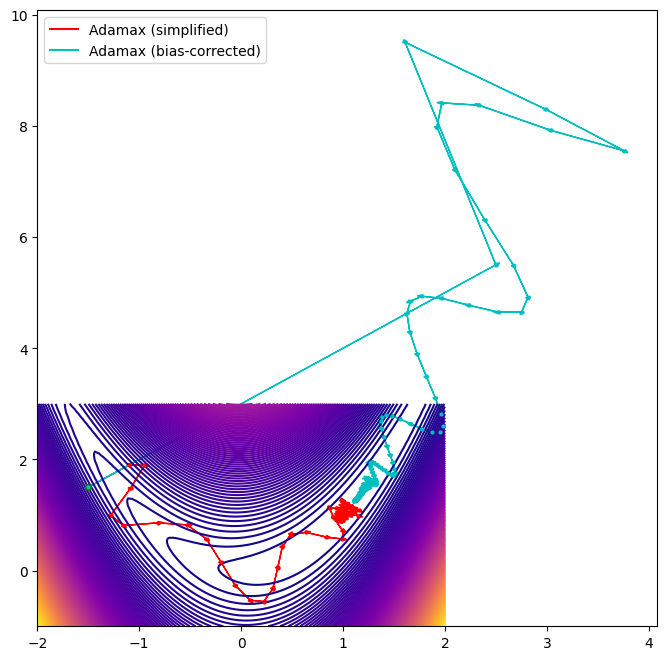

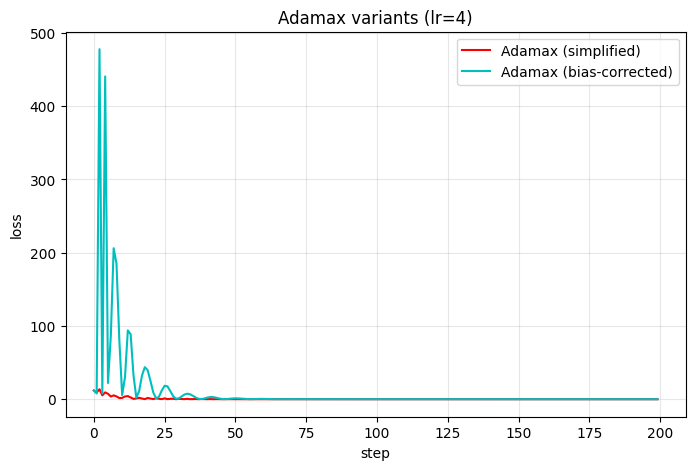

In [18]:
start = np.array([-1.5, 1.5])
lr = 4
steps = 200

path_s, loss_s = adamax_simplified(start, lr=lr, steps=steps)
path_b, loss_b = adamax_bias_corrected(start, lr=lr, steps=steps)

paths_and_labels = [
    (path_s, "Adamax (simplified)",     'r'),
    (path_b, "Adamax (bias-corrected)", 'c'),
]

losses_and_labels = [
    (loss_s, "Adamax (simplified)",     'r'),
    (loss_b, "Adamax (bias-corrected)", 'c'),
]

plot_optimizer_multi(xx, yy, zz, paths_and_labels, steps, start)
plot_loss_curve_multi(losses_and_labels, lr=lr, title_prefix='Adamax variants')


Finally, a comparison between Adam and Adammax (both using the simplified versions). Setting the learning rate to 4 provides a clear difference between the methods

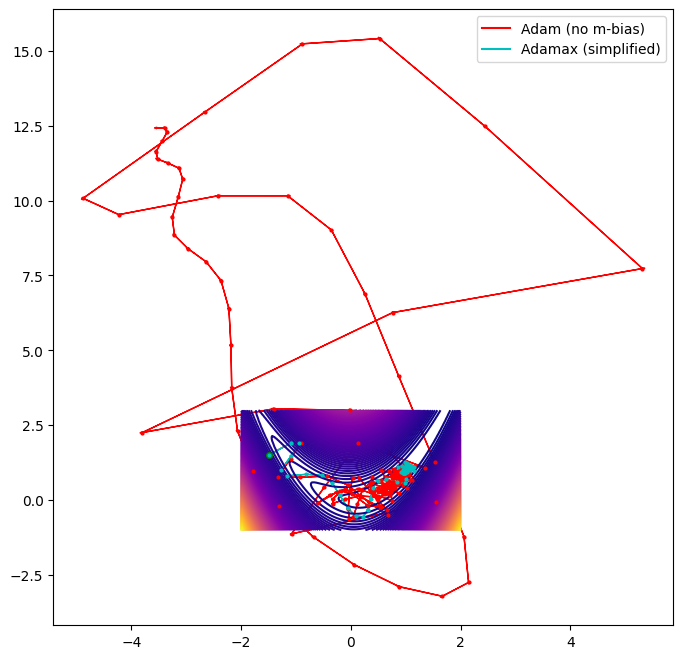

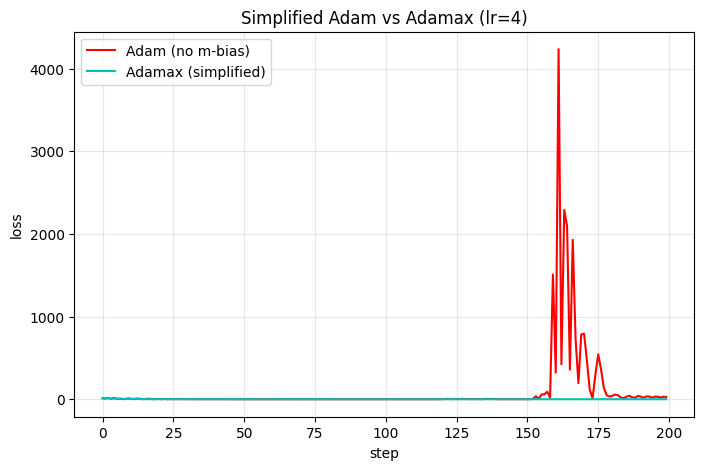

In [19]:
# Adam vs Adamax (simplified) using multi-plot helpers

start = np.array([-1.5, 1.5])
lr = 4
steps = 200

# run both simplified variants
path_adam_s,  loss_adam_s  = adam_no_m_bias(start,     lr=lr, steps=steps)
path_amax_s,  loss_amax_s  = adamax_simplified(start,  lr=lr, steps=steps)

# prepare inputs for multi-plot (path, label, color)
paths_and_labels = [
    (path_adam_s, "Adam (no m-bias)",     'r'),
    (path_amax_s, "Adamax (simplified)",  'c'),
]

losses_and_labels = [
    (loss_adam_s, "Adam (no m-bias)",     'r'),
    (loss_amax_s, "Adamax (simplified)",  'c'),
]

# plots
plot_optimizer_multi(xx, yy, zz, paths_and_labels, steps, start)
plot_loss_curve_multi(losses_and_labels, lr=lr, title_prefix="Simplified Adam vs Adamax")


## Suplementary Refs

* Sebastian Ruder, **An overview of gradient descent optimization algorithms**, [PDF](https://arxiv.org/abs/1609.04747)
* PyTorch documentation, **TORCH.OPTIM**, [LINK](https://pytorch.org/docs/stable/optim.html)
* Tensorflow documentation, **Module: tf.keras.optimizers**, [LINK](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)